In [1]:
import numpy as np
import matplotlib.pyplot as plt 
from pyuvdata import UVData
from hydra_pspec.utils import form_pseudo_stokes_vis
from astropy.units import Quantity

In [2]:
'''Loading test data'''

uvd=UVData()
uvd.read('test_data/vis-eor.uvh5')
antpairpols=uvd.get_antpairpols()
uvd=form_pseudo_stokes_vis(uvd)
eor_test=uvd.get_data(['xx'], force_copy=True)
freqs=uvd.freq_array
freqs=freqs.reshape(freqs.shape[1],) #[0]
lsts=uvd.lst_array
print("Freqs shape: {} lsts shape: {}".format(freqs.shape,lsts.shape))

uvd=UVData()
uvd.read('test_data/vis-ptsrc-gsm.uvh5')
uvd=form_pseudo_stokes_vis(uvd)
antpairpols=uvd.get_antpairpols()
fg_test=uvd.get_data(antpairpols[1], force_copy=True)
print("Fg_test shape: ",fg_test.shape)

uvd=UVData()
uvd.read('test_data/vis-eor-fgs.uvh5')
uvd=form_pseudo_stokes_vis(uvd)
vis_test=uvd.get_data((0, 1, 'xx'), force_copy=True)
freqs=uvd.freq_array
freqs=freqs.reshape(freqs.shape[1],) #[0]
lsts=uvd.lst_array
print("Freqs shape: {} lsts shape: {}".format(freqs.shape,lsts.shape))

Ntimes= len(lsts)
Nfreqs= len(freqs)


Freqs shape: (120,) lsts shape: (203,)
Fg_test shape:  (203, 120)
Freqs shape: (120,) lsts shape: (203,)


Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.


In [86]:
'''importing solved data'''

dir_name='results-seed-7123689-Niter-2_v1_airy_3/0-1/'
# dir_name = 'code_test/0-1/'
eor_sol=np.load(dir_name+'gcr-eor.npy').mean(axis=0)

fgmodes=np.load('test_data/fgmodes.npy')
fg_sol=np.load(dir_name+'fg-amps.npy').mean(axis=0) #fgamps saved as a product

fg_sol = fg_sol @ fgmodes[:,:12].T

print("EoR shape: {}\nFG shape: {}\n".format(eor_sol.shape,fg_sol.shape))

EoR shape: (203, 120)
FG shape: (203, 120)



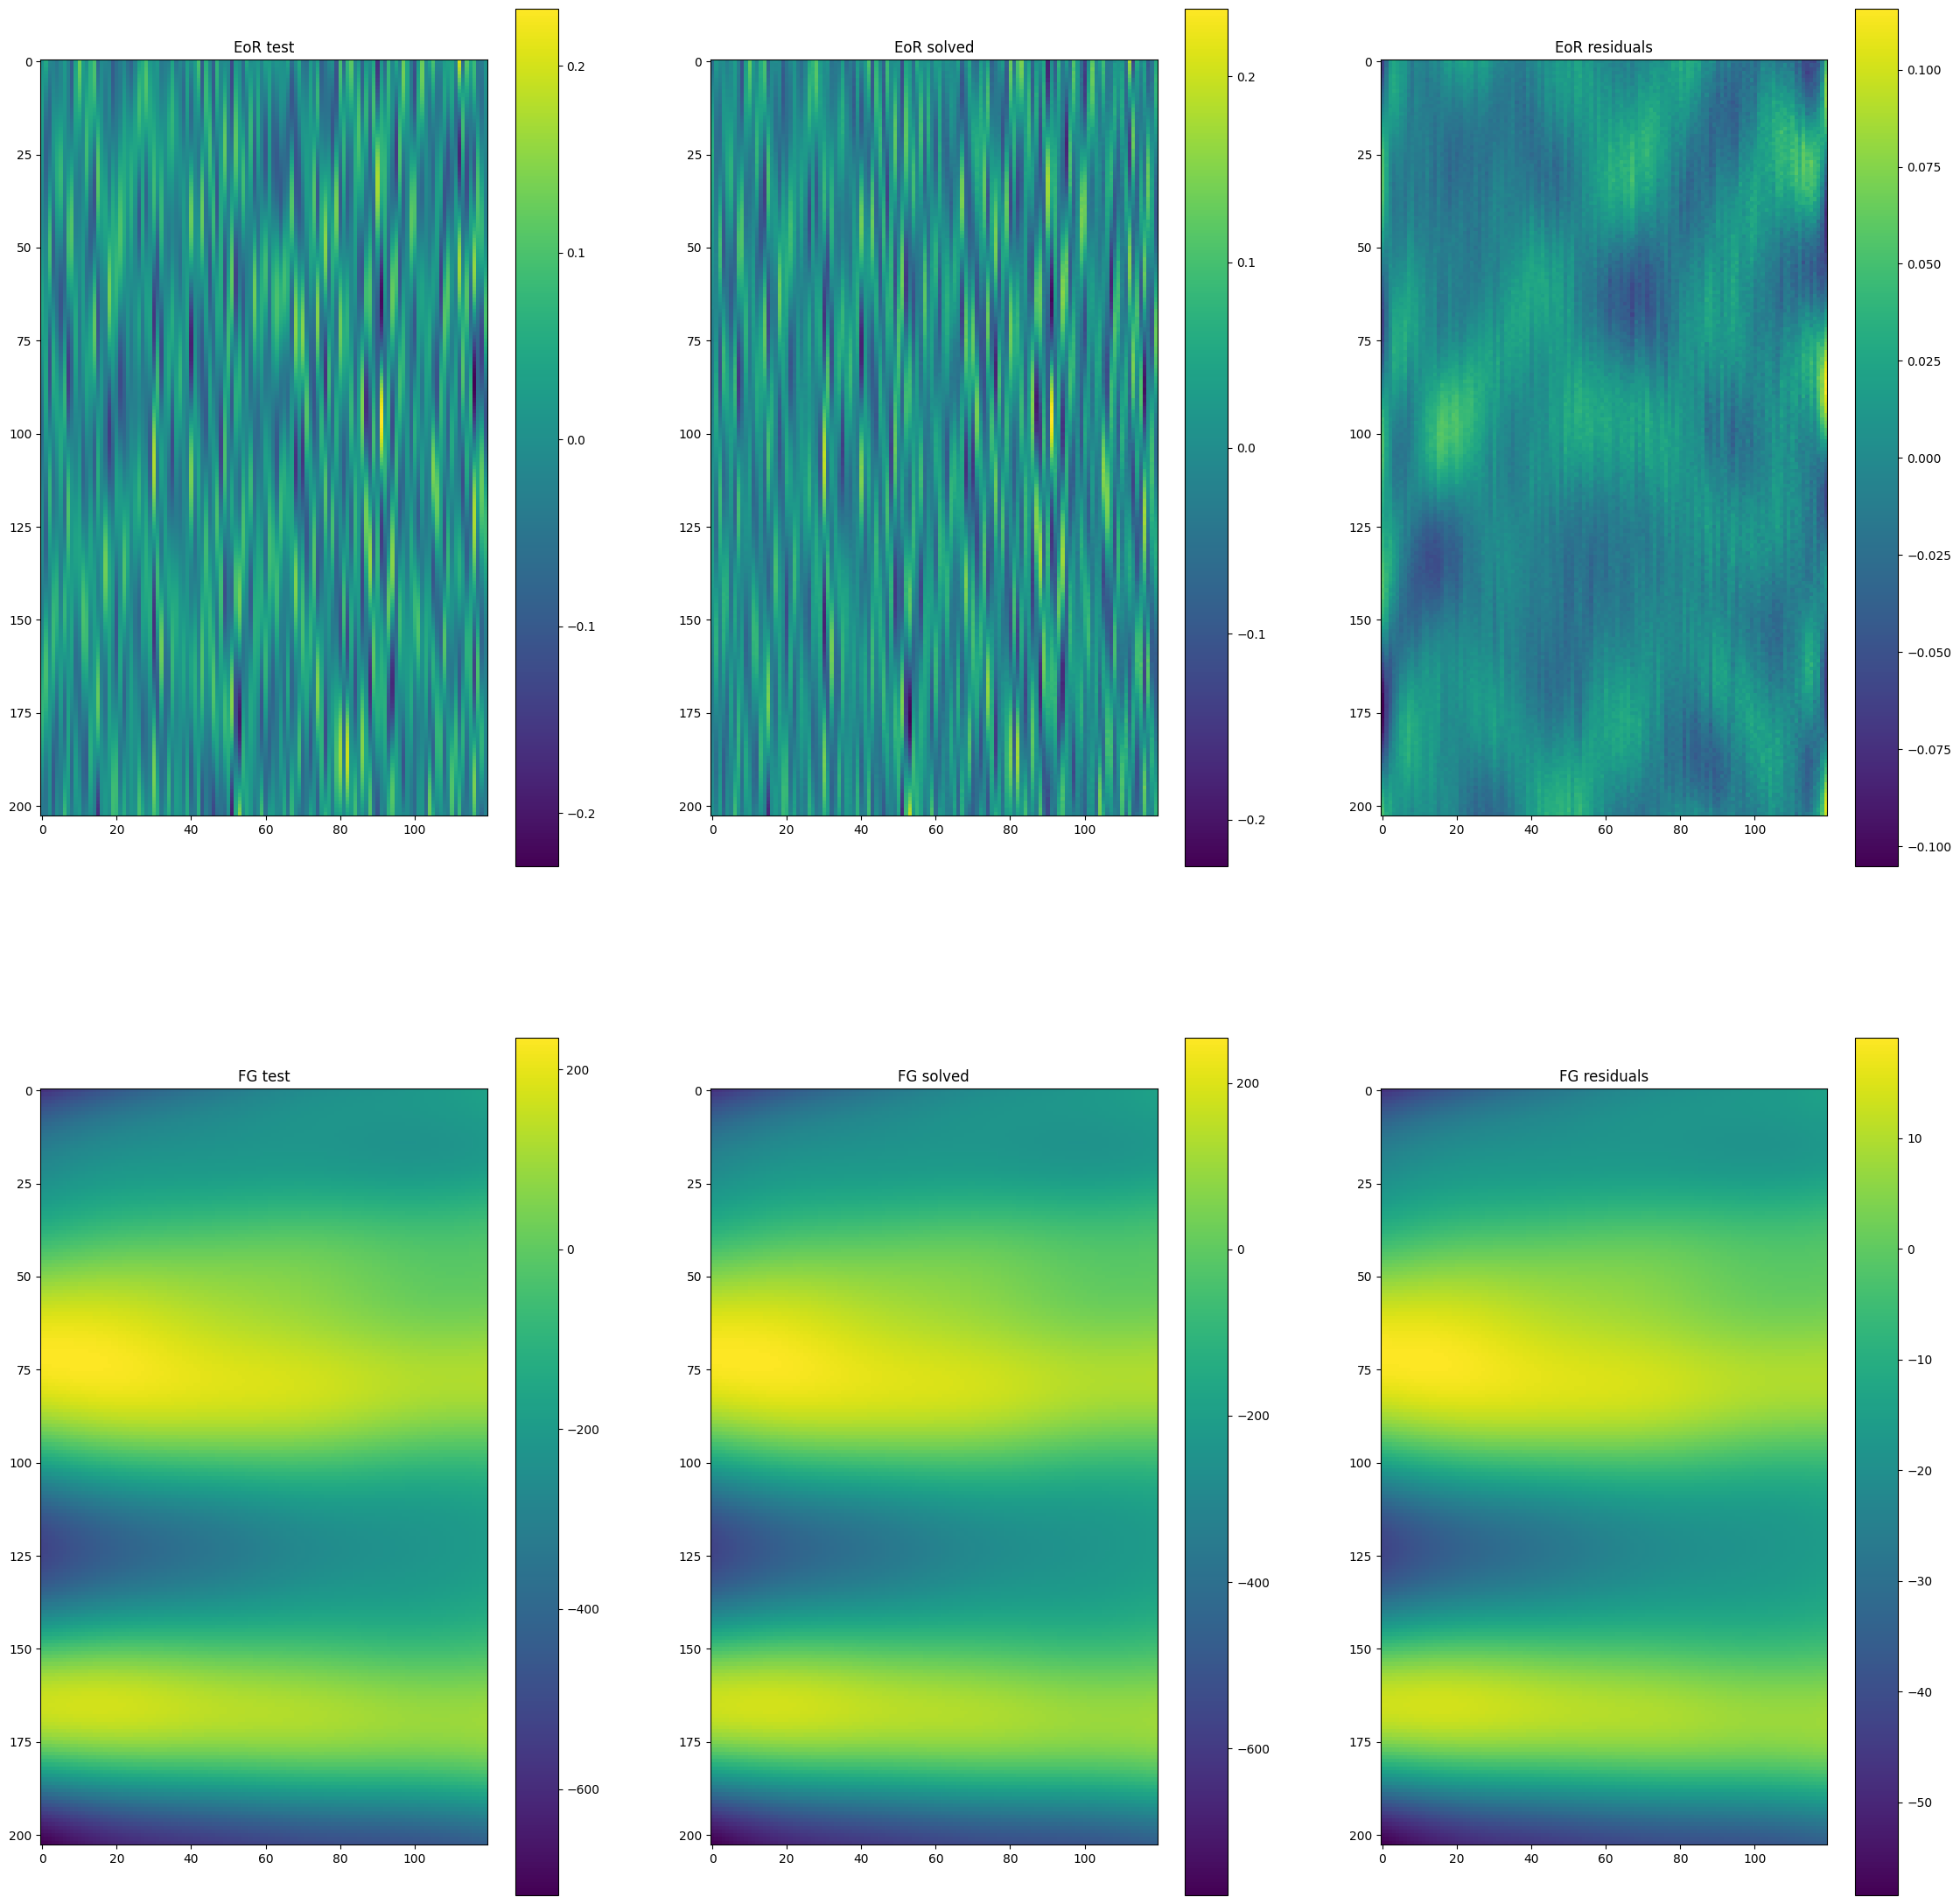

In [87]:
fig, ax = plt.subplots(2,3, figsize=(28,28))


im=ax[0,0].imshow(eor_test.real)
ax[0,0].set_title("EoR test")
plt.colorbar(im)

im=ax[0,1].imshow(eor_sol.real)
ax[0,1].set_title("EoR solved")
plt.colorbar(im)

im=ax[0,2].imshow(eor_sol.real-eor_test.real)
ax[0,2].set_title("EoR residuals")
plt.colorbar(im)

im=ax[1,0].imshow(2*fg_test.real)
ax[1,0].set_title("FG test")
plt.colorbar(im)

im=ax[1,1].imshow(fg_sol.real)
ax[1,1].set_title("FG solved")
plt.colorbar(im)

im=ax[1,2].imshow(fg_sol.real-2*fg_test.real)
ax[1,2].set_title("FG residuals")
plt.colorbar(im)


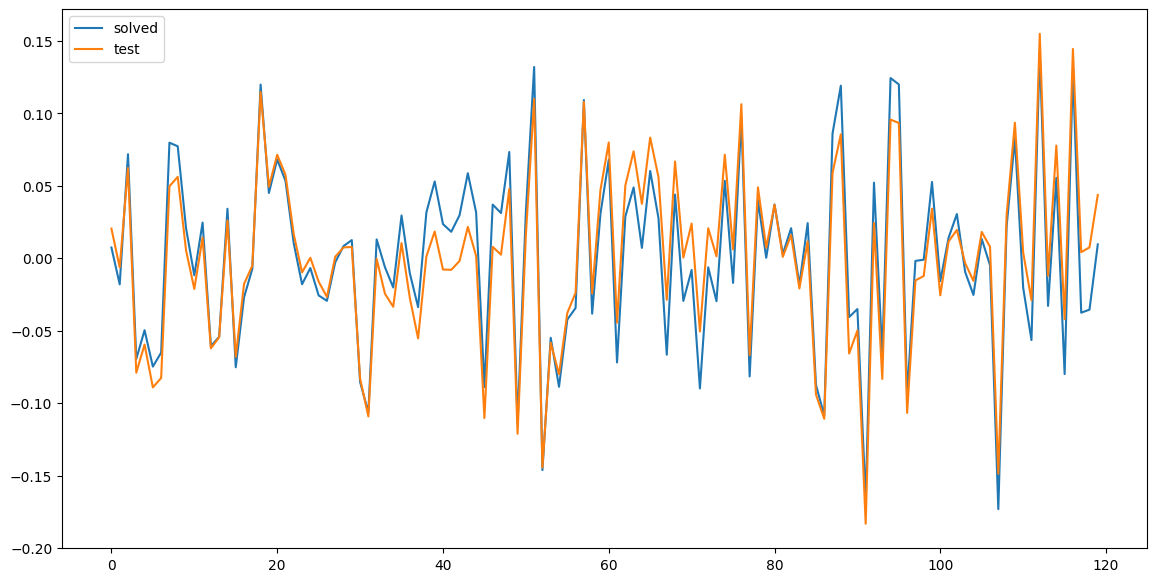

In [89]:
plt.figure(figsize=(14,7))
plt.plot(eor_sol.real[57,:] - np.mean(eor_sol.real[57,:]),label='solved')
plt.plot(eor_test.real[57,:] - np.mean(eor_test.real[57,:]),label='test')
# plt.plot(fgmodes[:,10], label='fgmodes')
# plt.plot(0.05+eor_test.real[0,:],label='twice of test', ls='--')
# plt.plot(eor_sol.real[0,:].real-eor_test[0,:].real,label='residual',ls='--')
plt.legend()

In [82]:
times = Quantity(np.unique(lsts * 12 / np.pi), unit='h')
freqs_mhz = Quantity(freqs/1e6, unit='Hz')

In [83]:
freqs_mhz[0]

<Quantity 100. Hz>

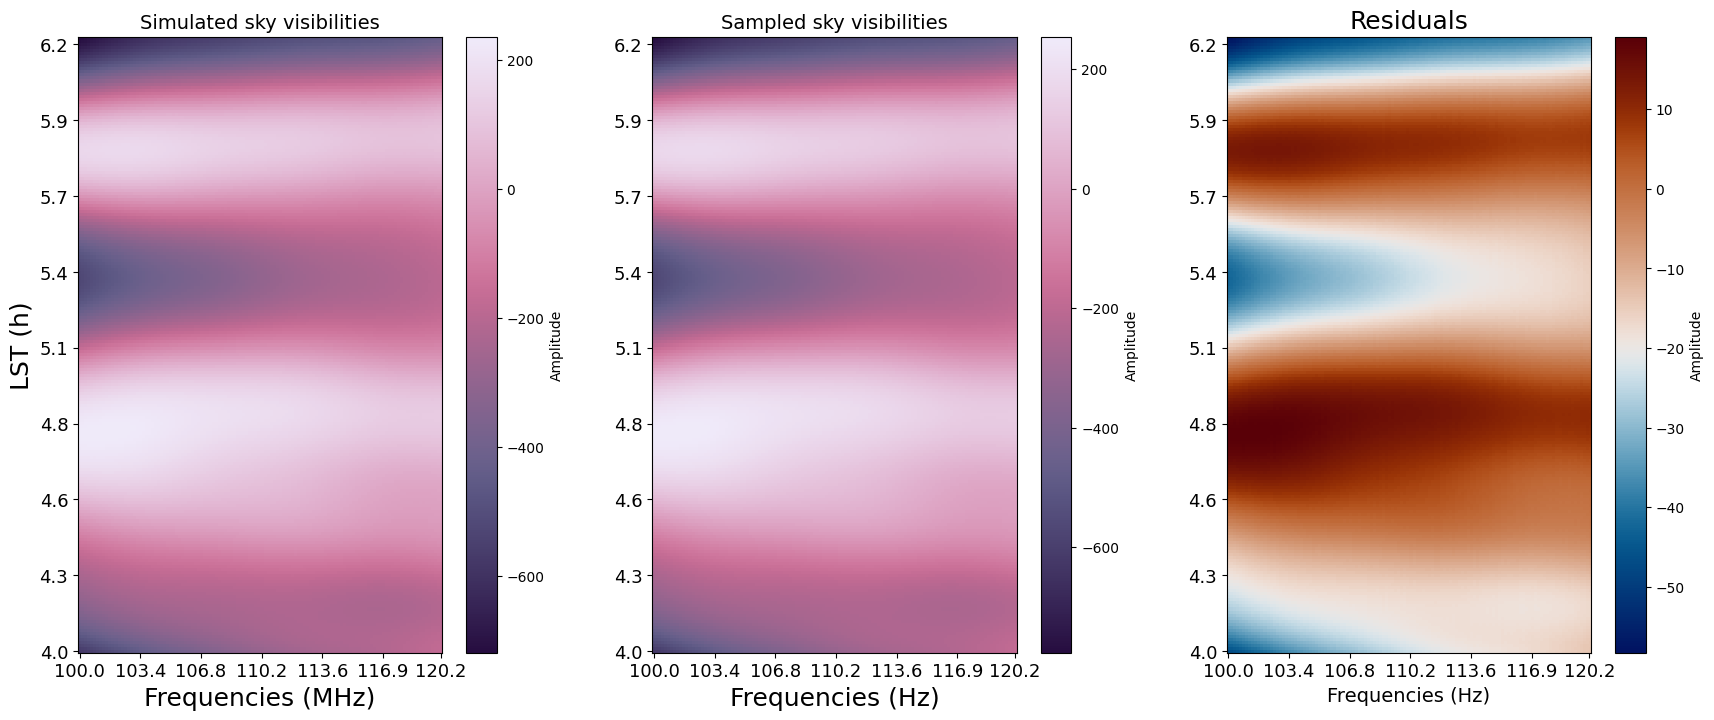

In [90]:
''' comparing visibilities '''
import cmcrameri.cm as cmc
import seaborn as ss
import matplotlib.ticker as ticker


# vis_test = np.load('test_files/divergence_tests_airy_v2_1/vis.npy')

# vis_sol = np.load('test_files/divergence_tests_airy_v2_1/sky_model_0.npy')
vis_sol = eor_sol + fg_sol

xticklocs=[0,20,40,60,80,100,119]
yticklocs=[0,25,50,75,100,125,150,175,200]

xstep = (freqs[-1]-freqs[0])/Nfreqs
ystep = (lsts[-1]-lsts[0])/Ntimes

# xticks= [freqs[0]+(x*xstep) for x in xticklocs]
# yticks= [lsts[0]+(x*xstep) for x in yticklocs]
xticks= freqs_mhz[xticklocs]
yticks=times[yticklocs]
noise = np.load('test_data/noise.npy')

fig, ax = plt.subplots(1,3,figsize=(21,8))
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6

for a in ax:
    a.set_xticks(xticklocs, labels=[f"{tick:.1f}" for tick in xticks.value], fontsize=13)
    a.set_yticks(yticklocs, labels=[f"{tick:.1f}" for tick in yticks.value], fontsize=13)


im=ax[0].imshow(2*vis_test.real, origin='lower',cmap=cmc.acton)
ax[0].set_title("Simulated sky visibilities", fontsize=14)
ax[0].set_xlabel('Frequencies (MHz)', fontsize=18)
ax[0].set_ylabel('LST (h)', fontsize=18)
plt.colorbar(im,label='Amplitude')

im=ax[1].imshow(vis_sol.real, origin='lower',cmap=cmc.acton)
ax[1].set_title("Sampled sky visibilities", fontsize=14)
ax[1].set_xlabel('Frequencies (Hz)', fontsize=18)
plt.colorbar(im,label='Amplitude')

im=ax[2].imshow(vis_sol.real-2*vis_test.real, origin='lower', cmap=cmc.vik) #, vmin= -3*np.std(noise), vmax=3*np.std(noise)
ax[2].set_title("Residuals", fontsize=18)
ax[2].set_xlabel('Frequencies (Hz)', fontsize=14)
plt.colorbar(im,label='Amplitude')

# plt.savefig('Visibility_sols.png',bbox_inches='tight',dpi=300, transparent=True)

In [70]:
type(yticks)

astropy.units.quantity.Quantity

In [71]:
np.max(vis_sol.real/vis_test.real)

17.1765117194002

B_sys shape:  (120,)
Test shape: (203, 120), Solved shape: (203, 120)


Telescope Hex37-14.6m is not in known_telescopes.
Telescope Hex37-14.6m is not in known_telescopes.


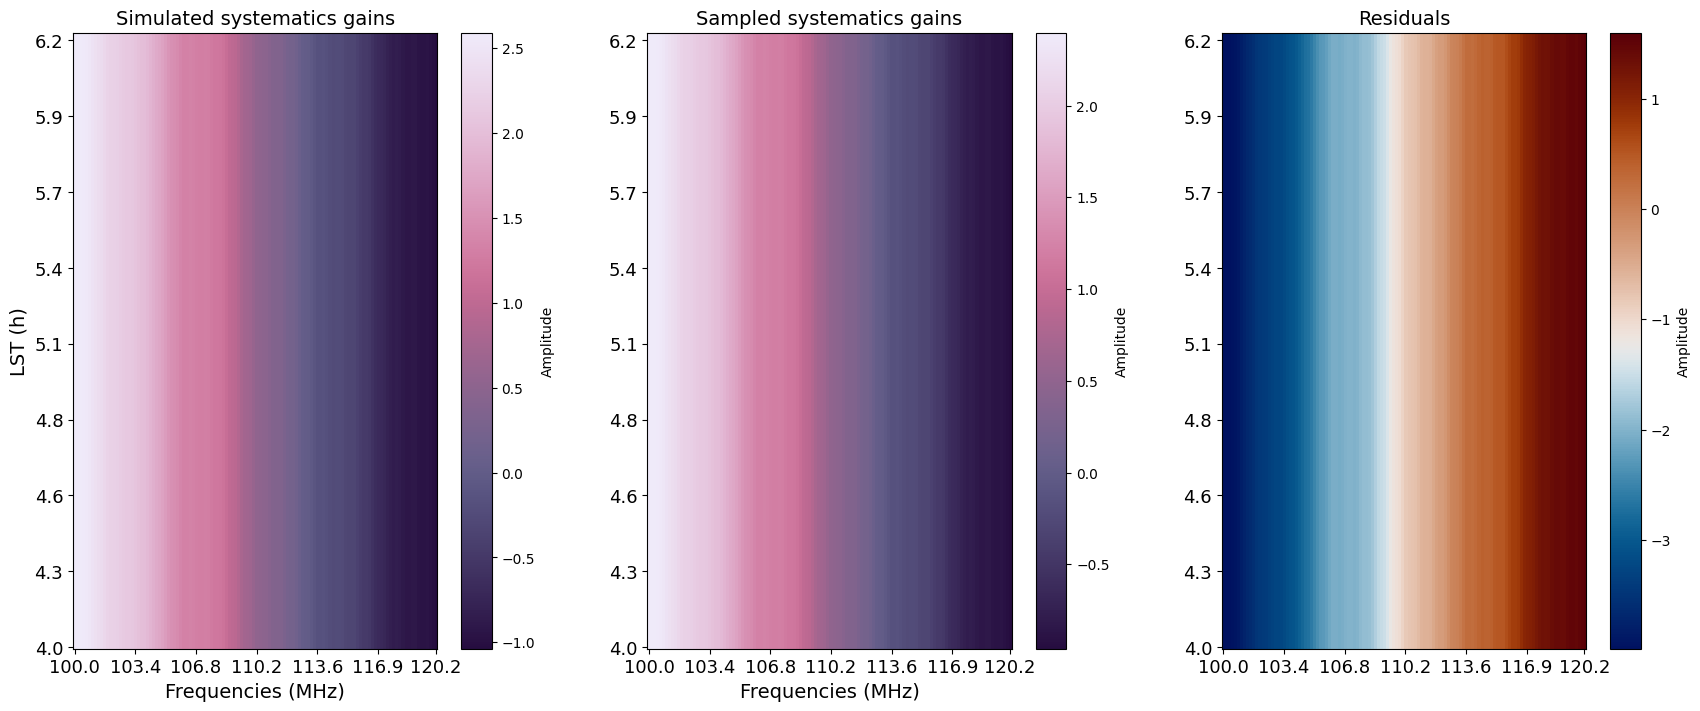

In [72]:

b_sys_solved = np.load(dir_name+"b-sys.npy").mean(axis=0)
print("B_sys shape: ",b_sys_solved.shape)
uvd=UVData()
uvd.read('hera_val/vis_corrupted_test.uvh5')
antpairpols=uvd.get_antpairpols()
uvd=form_pseudo_stokes_vis(uvd)
vis_corr=uvd.get_data(antpairpols[0], force_copy=True)

uvd=UVData()
uvd.read('test_data/vis-eor-fgs.uvh5')
antpairpols=uvd.get_antpairpols()
uvd=form_pseudo_stokes_vis(uvd)
clean_vis=uvd.get_data(antpairpols[0], force_copy=True)

# b_sys_past = np.load("test_files/divergence_tests_airy_v2_1/b_sys_past.npy")
h_j = np.load("test_files/divergence_tests_airy_v2_1/h_j_op.npy")
sys_model_solved = (h_j @ b_sys_solved).reshape([Ntimes,Nfreqs],order='F')
sys_model_test = vis_corr/clean_vis
# sys_model_test = np.reshape(sys_model_test,[len(lsts),len(freqs)],order='F')
print("Test shape: {}, Solved shape: {}".format(sys_model_test.shape,sys_model_solved.shape))

fig, ax = plt.subplots(1,3,figsize=(21,8))
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6

for a in ax:
    a.set_xticks(xticklocs, labels=[f"{tick:.1f}" for tick in xticks.value], fontsize=13)
    a.set_yticks(yticklocs, labels=[f"{tick:.1f}" for tick in yticks.value], fontsize=13)

im=ax[0].imshow(sys_model_test.real, origin='lower',cmap=cmc.acton)
ax[0].set_title("Simulated systematics gains", fontsize=14)
ax[0].set_xlabel('Frequencies (MHz)', fontsize=14)
ax[0].set_ylabel('LST (h)', fontsize=14)
plt.colorbar(im,label='Amplitude')

im=ax[1].imshow(2*sys_model_solved.real, origin='lower', cmap=cmc.acton)
ax[1].set_title("Sampled systematics gains", fontsize=14)
ax[1].set_xlabel('Frequencies (MHz)', fontsize=14)
plt.colorbar(im,label='Amplitude')

im=ax[2].imshow((sys_model_solved.real)-2*sys_model_test.real,  cmap=cmc.vik, origin='lower')
ax[2].set_title("Residuals", fontsize=14)
ax[1].set_xlabel('Frequencies (MHz)', fontsize=14)
plt.colorbar(im,label='Amplitude')

# plt.savefig('Systematics_sols.png',bbox_inches='tight',dpi=300, transparent=True)


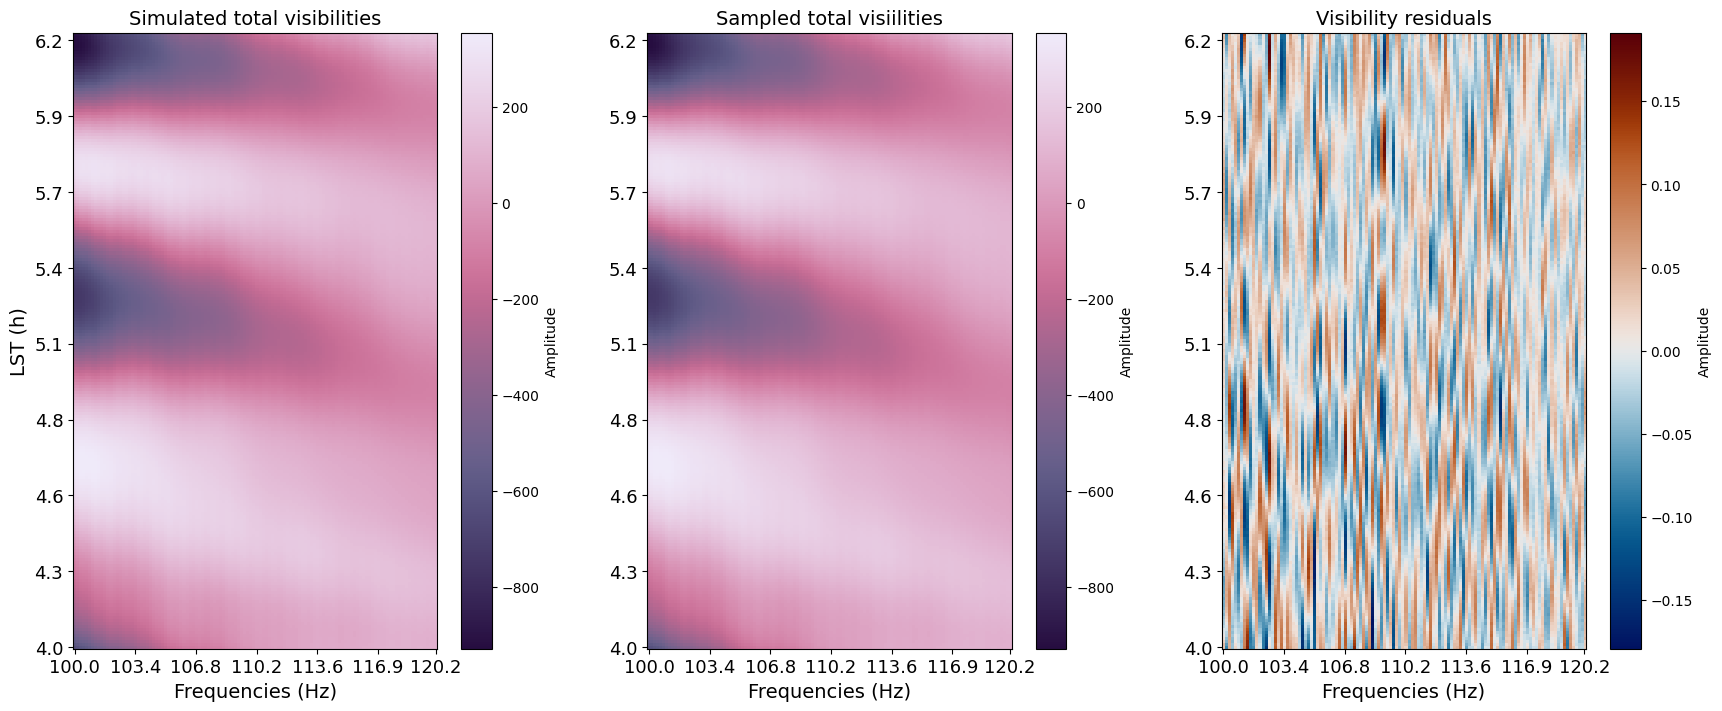

In [73]:
vis_corr_sol = sys_model_solved * vis_sol

''' comparing visibilities '''
import cmcrameri.cm as cmc
import seaborn as ss
import matplotlib.ticker as ticker


xticklocs=[0,20,40,60,80,100,119]
yticklocs=[0,25,50,75,100,125,150,175,200]

xstep = (freqs[-1]-freqs[0])/Nfreqs
ystep = (lsts[-1]-lsts[0])/Ntimes

# xticks= [freqs[0]+(x*xstep) for x in xticklocs]
# yticks= [lsts[0]+(x*xstep) for x in yticklocs]
xticks= freqs_mhz[xticklocs]
yticks=times[yticklocs]
noise = np.load('test_data/noise.npy')

fig, ax = plt.subplots(1,3,figsize=(21,8))
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6

for a in ax:
    a.set_xticks(xticklocs, labels=[f"{tick:.1f}" for tick in xticks.value], fontsize=13)
    a.set_yticks(yticklocs, labels=[f"{tick:.1f}" for tick in yticks.value], fontsize=13)



im=ax[0].imshow(vis_corr.real, origin='lower',cmap=cmc.acton)
ax[0].set_title("Simulated total visibilities", fontsize=14)
ax[0].set_xlabel('Frequencies (Hz)', fontsize=14)
ax[0].set_ylabel('LST (h)', fontsize=14)
plt.colorbar(im,label='Amplitude')

im=ax[1].imshow(vis_corr_sol.real, origin='lower',cmap=cmc.acton)
ax[1].set_title("Sampled total visiilities", fontsize=14)
ax[1].set_xlabel('Frequencies (Hz)', fontsize=14)
# ax[1].set_ylabel('Times')
plt.colorbar(im,label='Amplitude')

im=ax[2].imshow((vis_corr_sol.real-vis_corr.real), origin='lower', cmap=cmc.vik) #, vmin= -3*np.std(noise), vmax=3*np.std(noise)
ax[2].set_title("Visibility residuals", fontsize=14)
ax[2].set_xlabel('Frequencies (Hz)', fontsize=14)
# ax[2].set_ylabel('Times')
plt.colorbar(im,label='Amplitude')

# plt.savefig('Corrupted_visibility_sols.png',bbox_inches='tight',dpi=300, transparent=True)

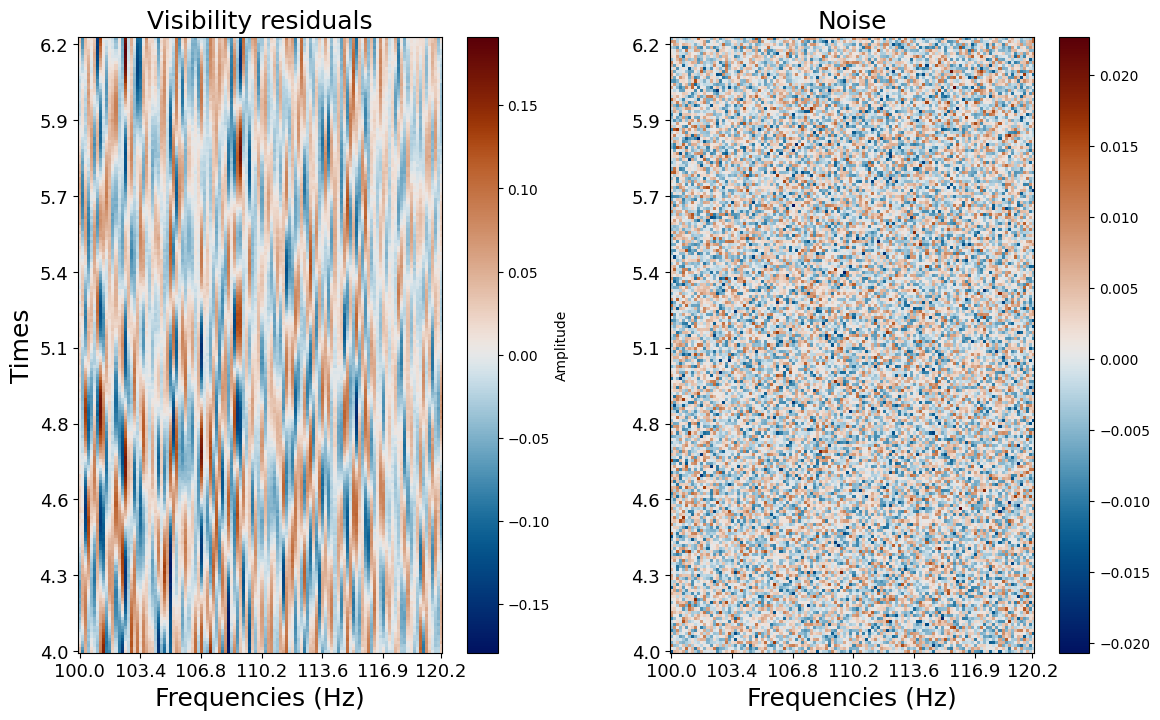

In [74]:
fig, ax = plt.subplots(1,2,figsize=(14,8))
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_powerlimits((6, 6))  # Force sci notation for values >= 1e6

for a in ax:
    a.set_xticks(xticklocs, labels=[f"{tick:.1f}" for tick in xticks.value], fontsize=13)
    a.set_yticks(yticklocs, labels=[f"{tick:.1f}" for tick in yticks.value], fontsize=13)

im=ax[0].imshow((vis_corr_sol.real-vis_corr.real), origin='lower', cmap=cmc.vik) #, vmin= -3*np.std(noise), vmax=3*np.std(noise)
ax[0].set_title("Visibility residuals", fontsize=18)
ax[0].set_xlabel('Frequencies (Hz)', fontsize=18)
ax[0].set_ylabel('Times', fontsize=18)
plt.colorbar(im,label='Amplitude')

im=ax[1].imshow(noise.real, origin='lower', cmap=cmc.vik) #, vmin= -3*np.std(noise), vmax=3*np.std(noise)
ax[1].set_title("Noise", fontsize=18)
ax[1].set_xlabel('Frequencies (Hz)', fontsize=18)
plt.colorbar(im)

# plt.savefig('Res_comp_w_noise.png',bbox_inches='tight',dpi=300, transparent=True)


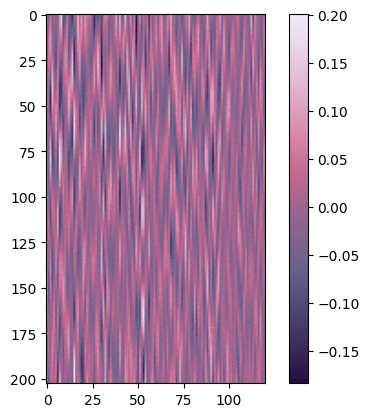

In [75]:
plt.imshow((vis_corr_sol.real-vis_corr.real)-noise.real,cmap=cmc.acton)
plt.colorbar()

EoR shape: (203, 120)
FG shape: (203, 120)



Text(0.5, 1.0, 'Residuals')

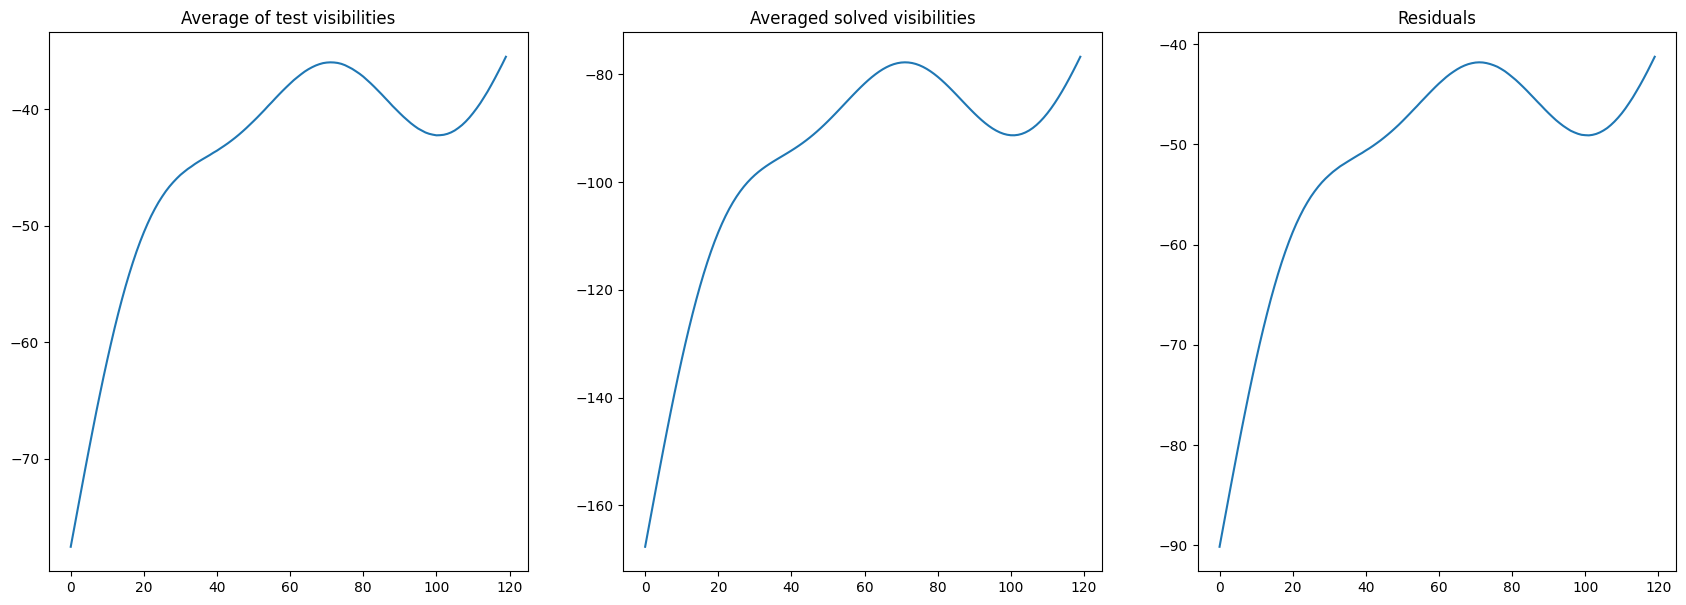

In [76]:
''' comparing visibilities '''

'''importing solved data'''

dir_name='test_files/divergence_tests_airy_v2_1/'

eor=np.load(dir_name+'eor-gcr.npy')

fg=np.load(dir_name+'fg-amps.npy')

eor_avg = np.mean(eor, axis=0)
fg_avg = np.mean(fg, axis=0)

# fg_avg = fg_avg @ fgmodes[:,:12].T
vis_avg = eor_avg + fg_avg
print("EoR shape: {}\nFG shape: {}\n".format(eor_sol.shape,fg_sol.shape))

vis_test_avg = np.mean(vis_test, axis=0)
fig, ax = plt.subplots(1,3,figsize=(21,7))

im=ax[0].plot(vis_test_avg.real)
ax[0].set_title("Average of test visibilities")
# plt.colorbar(im)

im=ax[1].plot(vis_avg.real)
ax[1].set_title("Averaged solved visibilities")
# plt.colorbar(im)

ax[2].plot(vis_avg.real-vis_test_avg.real,)
ax[2].set_title("Residuals")
# # plt.colorbar(im)

In [77]:
import scipy as sp

cov_eor_test = np.load('test_data/eor-cov.npy')

Eh=sp.linalg.sqrtm(cov_eor_test)  

omi, omj = np.random.randn(120, 203), np.random.randn(120,1)
omk, oml = np.random.randn(120, 203), np.random.randn(120,1)
oma, omb = (omi + 1.0j * omj) / 2**0.5, (omk + 1.0j * oml) / 2**0.5

# oma = np.zeros((120, 1), dtype=complex)
# omb = np.zeros((120, 1), dtype=complex)

eh_prod = Eh @ oma

In [78]:
(eh_prod.T-eor_test).shape

(203, 120)

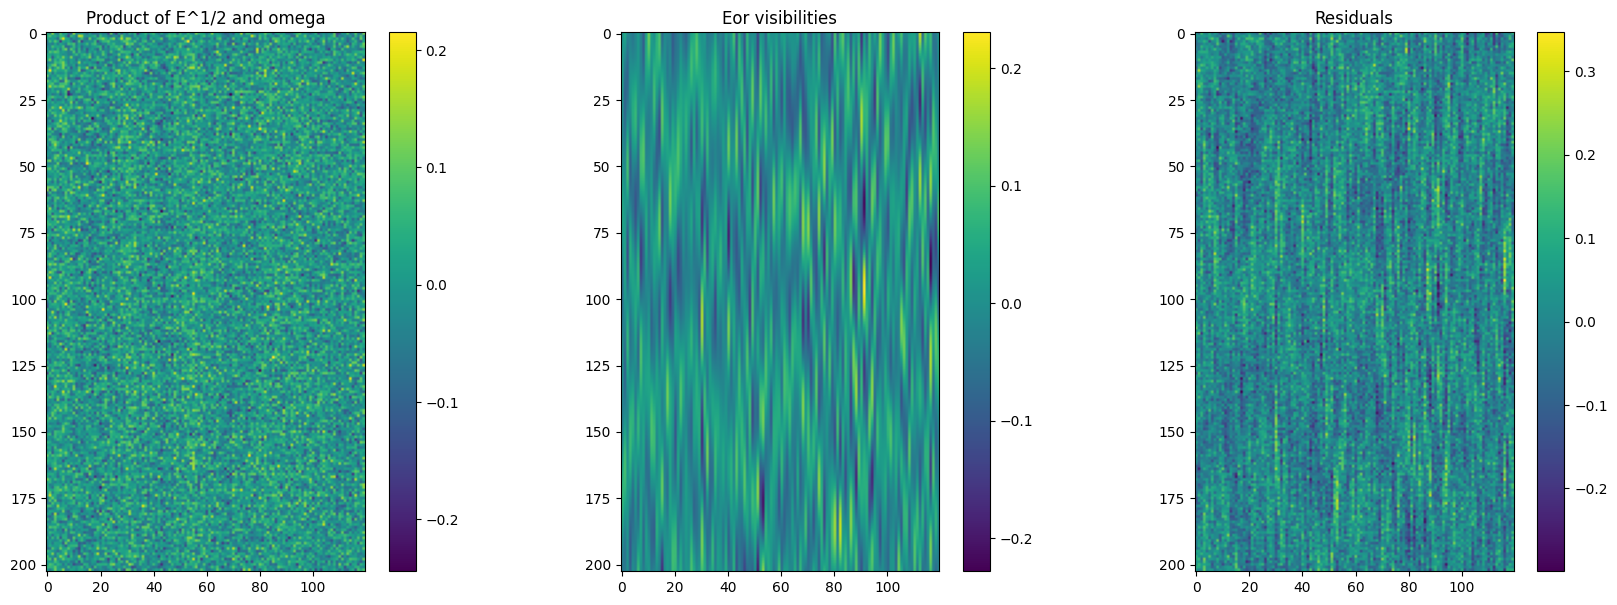

In [79]:
fig, ax = plt.subplots(1,3,figsize=(21,7))

im=ax[0].imshow(eh_prod.T.real, label='Product of E^1/2 and omega')
ax[0].set_title("Product of E^1/2 and omega")
plt.colorbar(im)

im=ax[1].imshow(eor_test.real, label='Eor visibilities')
ax[1].set_title("Eor visibilities")
plt.colorbar(im)

im=ax[2].imshow((eh_prod.T-eor_test).real,  label='Residuals')
ax[2].set_title("Residuals")
plt.colorbar(im)

In [ ]:
fg_amps_solved = np.load(dir_name+'fg-amps.npy')

In [ ]:
fg_amps_solved.shape

(1000, 203, 12)

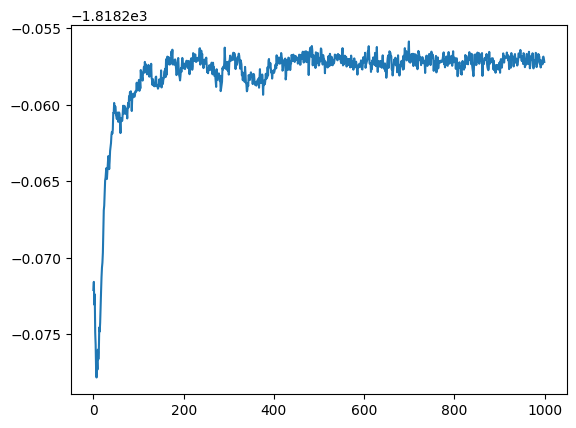

In [ ]:
plt.plot(fg_amps_solved[:,0,0].real)

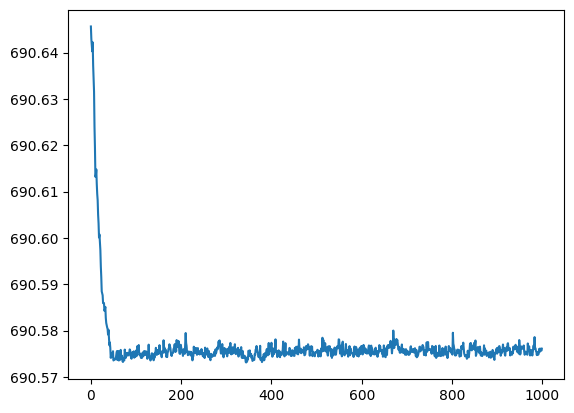

In [ ]:
plt.plot(fg_amps_solved[:,0,0].imag)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pyuvdata import UVData
import scipy as sp
from multiprocess import Pool, current_process
uvd=UVData()
import time
from uvtools.dspec import gen_window
from uvtools.utils import FFT, fourier_freqs
from astropy import constants, units
import itertools
from scipy.sparse.linalg import cg


def data_dly_fr(data, freqs, times, windows=None,
                    freq_window_kwargs=None, time_window_kwargs=None):
    """
    Transform data to delay fringe-rate space
    
    This function takes a 2D array of visibility data (in units of Jy), as well 
    as the corresponding frequency and time arrays (in units of Hz and JD, respectively), 
    and makes a 2x2 grid of plots where each plot shows each one of the possible choices 
    for Fourier transforming along an axis. The upper-left plot is in the frequency-time 
    domain; the upper-right plot is in the frequency-fringe-rate domain; the lower-left 
    plot is in the delay-time domain; and the lower-right plot is in the delay-fringe-rate 
    domain.
    
    Parameters
    ----------
    data : ndarray, shape=(NTIMES,NFREQS)
        Array containing the visibility to be plotted. Assumed to be in units of Jy. 
        
    freqs : ndarray, shape=(NFREQS,)
        Array containing the observed frequencies. Assumed to be in units of Hz.
        
    times : ndarray, shape=(NTIMES,)
        Array containing the observed times. Assumed to be in units of JD.
        
    windows : tuple of str or str, optional
        Choice of taper to use for the fringe-rate and delay transforms. Must be 
        either tuple, list, or string. If a tuple or list, then it must be either 
        length 1 or length 2; if it is length 2, then the zeroth entry is the taper 
        to be applied along the time axis for the fringe-rate transform, with the 
        other entry specifying the taper to be applied along the frequency axis 
        for the delay transform. Each entry is passed to uvtools.dspec.gen_window. 
        If ``windows`` is a length 1 tuple/list or a string, then it is assumed 
        that the same taper is to be used for both axes. Default is to use no 
        taper (or, equivalently, a boxcar).

    freq_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        frequency taper. Default is to pass no keyword arguments.
        
    time_window_kwargs : dict, optional
        Keyword arguments to pass to uvtools.dspec.gen_window for generating the 
        time taper. Default is to pass no keyword arguments.
    
    Returns
    -------
    data_dl_fr :
        data in delay-fringe rate space
    """
    # do some data prep
    freq_window_kwargs = freq_window_kwargs or {}
    time_window_kwargs = time_window_kwargs or {}
    if windows is not None:
        time_window = gen_window(windows, times.size, **time_window_kwargs)
        freq_window = gen_window(windows, freqs.size, **freq_window_kwargs)
    else:
        time_window = gen_window(None, times.size, **time_window_kwargs)
        freq_window = gen_window(None, freqs.size, **freq_window_kwargs)
        
    time_window = time_window[:, None]
    freq_window = freq_window[None, :]
    # data_fr = FFT(data * time_window, axis=0)
    # data_dly = FFT(data * freq_window, axis=1)
    data_fr_dly = FFT(FFT(data * time_window, axis=0) * freq_window, axis=1)
    
    fringe_rates = fourier_freqs(times * units.day.to('s')) * 1e3 # mHz
    dlys = fourier_freqs(freqs) * 1e9 # ns

    return data_fr_dly, dlys, fringe_rates

In [ ]:
residuals_dlfr, dlys, fr = data_dly_fr(vis_sol-vis_test, freqs, lsts, windows='blackman-harris')

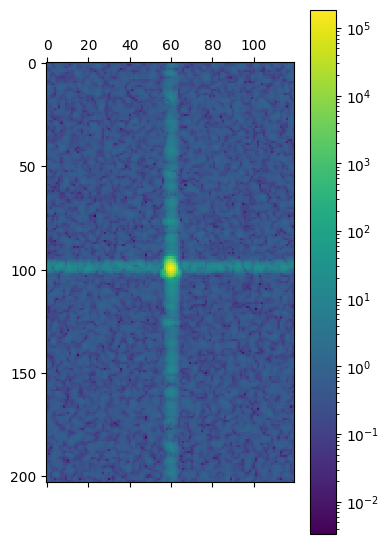

In [ ]:
plt.matshow(np.abs(residuals_dlfr), norm='log')
plt.colorbar()

In [ ]:
ls test_data/0-1

eor-cov.npy    fgmodes.npy    noise-cov.npy  noise.npy


In [ ]:
cov_eor_sol = np.load(dir_name+'cov-eor.npy')

cov_eor_test = np.load('test_data/0-1/eor-cov.npy')

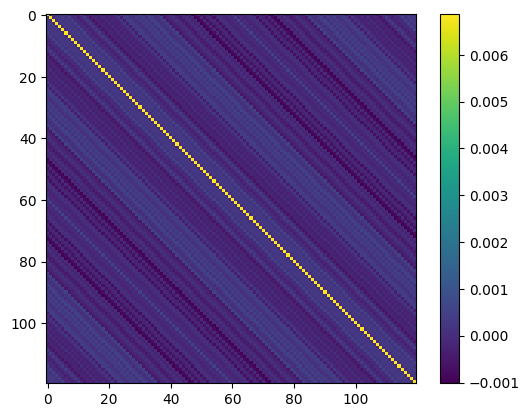

In [ ]:
plt.imshow(cov_eor_sol.real)
plt.colorbar()

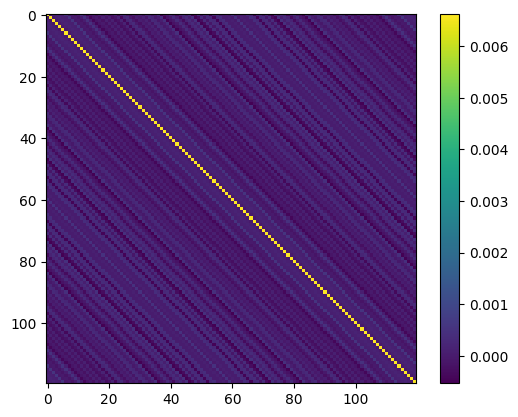

In [ ]:
plt.imshow(cov_eor_test.real)
plt.colorbar()

In [ ]:
ls

3bl-example.md
README.md
config-3bl-mpi.yaml
config-scaling-test.yaml
create_jobscript.sh
environment.yaml
example.py
hydra_pspec/
jobscript.sh.template
plot_speed_up.py
pyproject.toml
results-seed-7123689-Niter-1000/
results-seed-7123689-Niter-1000-2025-02-12T13:14:56.329955/
results_test.ipynb
run-hydra-pspec.py
scaling_tests_README.md
scripts/
set_up_scaling_data.py
strong_scaling_plots/
test_data/


In [ ]:
import hydra_pspec

uvd=UVData()
uvd.read('test_data/vis-eor-fgs.uvh5')
antpairpols = uvd.get_antpairpols()
uvd = hydra_pspec.utils.form_pseudo_stokes_vis(uvd)
vis_test_stokes=uvd.get_data((0, 1, 'xx'))
freqs=uvd.freq_array
freqs=freqs.reshape(freqs.shape[1],) #[0]
lsts=uvd.lst_array
print("Freqs shape: {} lsts shape: {}".format(freqs.shape,lsts.shape))

Freqs shape: (120,) lsts shape: (203,)


Telescope Hex37-14.6m is not in known_telescopes.


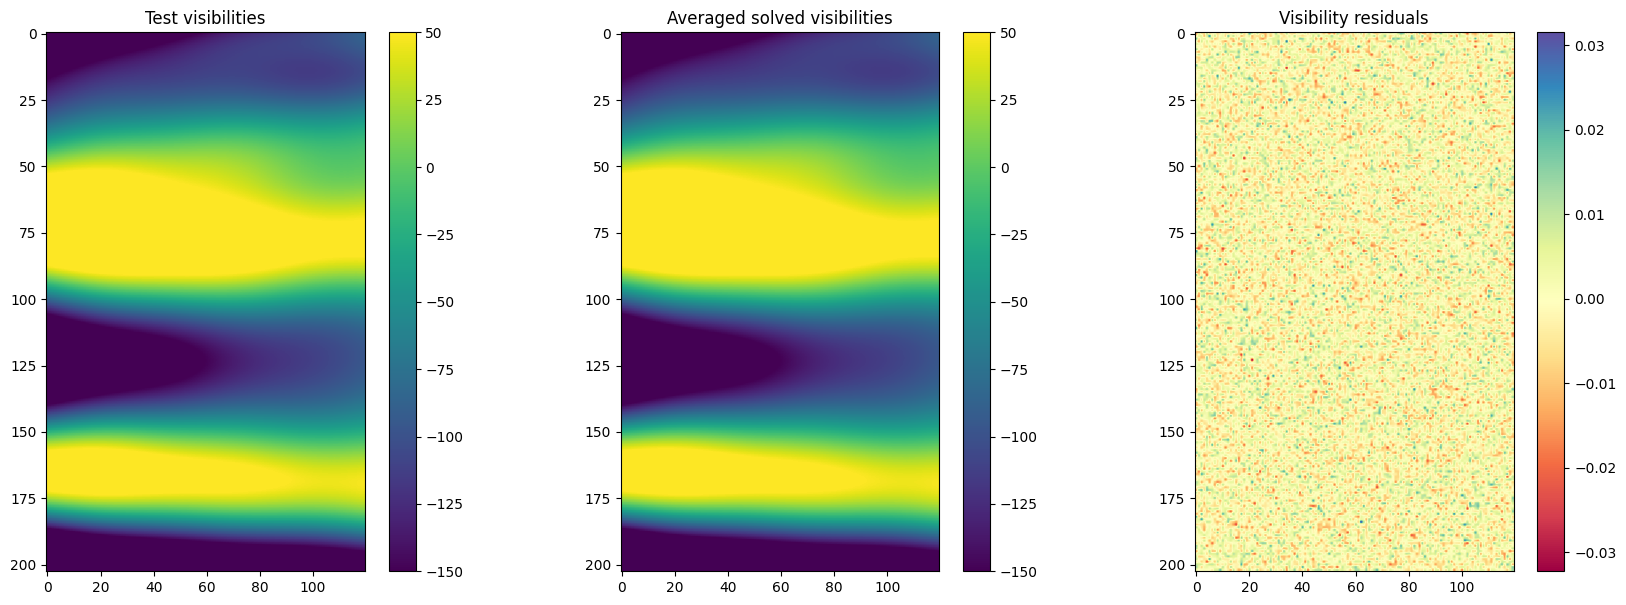

In [ ]:
fig, ax = plt.subplots(1,3,figsize=(21,7))

im=ax[0].imshow(vis_test_stokes.real, vmin=-150, vmax=50)
ax[0].set_title("Test visibilities")
plt.colorbar(im)

im=ax[1].imshow(vis_avg.real, vmin=-150, vmax=50)
ax[1].set_title("Averaged solved visibilities")
plt.colorbar(im)

im=ax[2].imshow(vis_avg.real-vis_test_stokes.real, cmap='Spectral')
ax[2].set_title("Visibility residuals")
plt.colorbar(im)

In [165]:
nm=[]
for i in range(120):
    nm.append([i,0])

In [168]:
type(nm),np.shape(nm)

(list, (120, 2))

In [169]:
nmog=[[0, 0], [49, 0],]
type(nmog),np.shape(nmog)

(list, (2, 2))